In [93]:
import pandas as pd
import numpy as np

In [94]:
traindf = pd.read_csv('../data/train.csv')
testdf = pd.read_csv('../data/test.csv')
df = pd.concat([traindf,testdf],axis = 0)



In [95]:
df.set_index('id',inplace = True)

In [96]:
df.isna().sum()

gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
Churn               254655
dtype: int64

In [97]:
columns = df.columns.tolist()
columns = [col for col in columns if col not in ['id', 'tenure','MonthlyCharges','TotalCharges']]
{col : df[col].unique().tolist() for col in columns}

{'gender': ['Male', 'Female'],
 'SeniorCitizen': [0, 1],
 'Partner': ['Yes', 'No'],
 'Dependents': ['Yes', 'No'],
 'PhoneService': ['Yes', 'No'],
 'MultipleLines': ['No', 'Yes', 'No phone service'],
 'InternetService': ['DSL', 'Fiber optic', 'No'],
 'OnlineSecurity': ['Yes', 'No', 'No internet service'],
 'OnlineBackup': ['No', 'Yes', 'No internet service'],
 'DeviceProtection': ['Yes', 'No', 'No internet service'],
 'TechSupport': ['Yes', 'No', 'No internet service'],
 'StreamingTV': ['No', 'Yes', 'No internet service'],
 'StreamingMovies': ['No', 'Yes', 'No internet service'],
 'Contract': ['One year', 'Two year', 'Month-to-month'],
 'PaperlessBilling': ['Yes', 'No'],
 'PaymentMethod': ['Mailed check',
  'Credit card (automatic)',
  'Electronic check',
  'Bank transfer (automatic)'],
 'Churn': ['No', 'Yes', nan]}

In [98]:
df['hasInternet'] = df['InternetService'].apply(lambda x: 0 if x == 'No' else 1)

internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})

df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': 0})


In [99]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,hasInternet
id,,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,0,DSL,1,0,...,1,0,0,One year,Yes,Mailed check,60.10,1653.85,No,1
1,Male,0,Yes,Yes,58,Yes,0,DSL,1,1,...,1,1,0,Two year,No,Credit card (automatic),69.50,3778.20,No,1
2,Male,0,Yes,No,58,Yes,1,Fiber optic,0,1,...,0,1,1,Month-to-month,Yes,Electronic check,100.40,5841.35,No,1
3,Female,0,No,No,1,Yes,0,Fiber optic,0,0,...,0,0,0,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,1
4,Female,0,No,No,1,Yes,0,Fiber optic,0,0,...,0,0,0,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,1


In [100]:
yesno_cols = ['Partner','Dependents','PhoneService','Churn','PaperlessBilling']
    
def gender_map(sex):
    if sex == "Male":
        return 1
    else:
        return 0
    
df[yesno_cols] = df[yesno_cols].replace({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map(gender_map)

/var/folders/db/4m8dhthn51d8sxyp9mp9sd_00000gn/T/ipykernel_20584/1737764466.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yesno_cols] = df[yesno_cols].replace({'Yes': 1, 'No': 0})


In [101]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,hasInternet
id,,,,,,,,,,,,,,,,,,,,,
0,1,0,1,1,29,1,0,DSL,1,0,...,1,0,0,One year,1,Mailed check,60.10,1653.85,0.0,1
1,1,0,1,1,58,1,0,DSL,1,1,...,1,1,0,Two year,0,Credit card (automatic),69.50,3778.20,0.0,1
2,1,0,1,0,58,1,1,Fiber optic,0,1,...,0,1,1,Month-to-month,1,Electronic check,100.40,5841.35,0.0,1
3,0,0,0,0,1,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,69.70,70.70,1.0,1
4,0,0,0,0,1,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,70.45,70.45,1.0,1


In [102]:
numerical_cols = ['tenure','MonthlyCharges','TotalCharges']

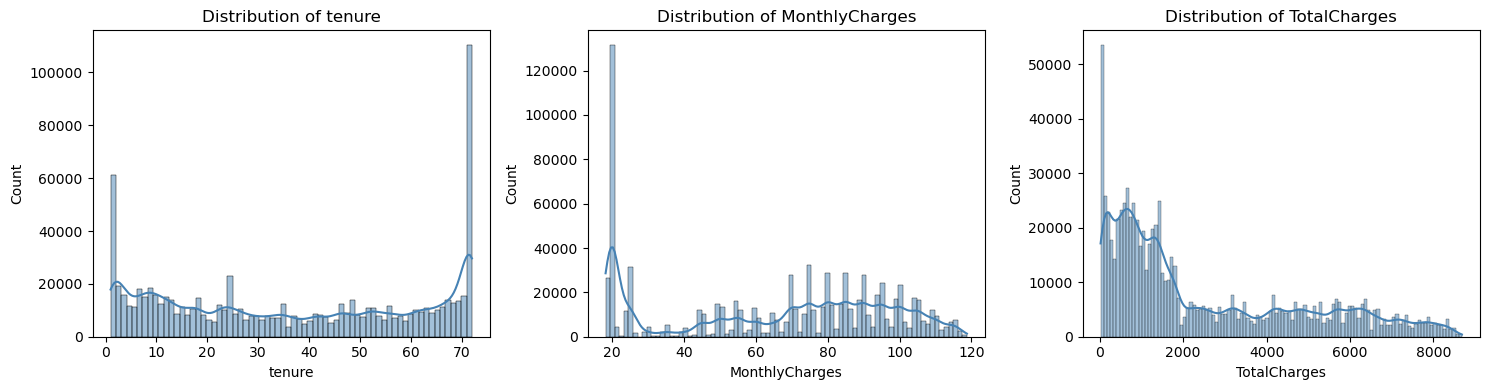

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [104]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,hasInternet
id,,,,,,,,,,,,,,,,,,,,,
0,1,0,1,1,29,1,0,DSL,1,0,...,1,0,0,One year,1,Mailed check,60.10,1653.85,0.0,1
1,1,0,1,1,58,1,0,DSL,1,1,...,1,1,0,Two year,0,Credit card (automatic),69.50,3778.20,0.0,1
2,1,0,1,0,58,1,1,Fiber optic,0,1,...,0,1,1,Month-to-month,1,Electronic check,100.40,5841.35,0.0,1
3,0,0,0,0,1,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,69.70,70.70,1.0,1
4,0,0,0,0,1,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,70.45,70.45,1.0,1


In [105]:
categorical_cols = ['PaymentMethod','Contract','InternetService']
df = pd.get_dummies(df,columns =categorical_cols,drop_first = True)

In [106]:
df.to_csv('../handled/feature_encoded.csv',index = False)